In [33]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal
from overview import FigureType, feature_overview

import numpy as np
import pandas as pd
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline

from processors import temparature, season, month
from transforming import (
    Apply, Bins, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, roc_auc_score
import matplotlib.pyplot as plt


def checkup(estimator_base, X, y, folds=7):
    metrics = []
    # kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    kf = KFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict_proba(X.loc[train]).T[1]
        pv = estimator.predict_proba(X.loc[valid]).T[1]

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


def linear_feature_importances(estimator, **kwargs):
    index = (-estimator.coef_).argsort()
    values = estimator.coef_[:, *index]
    labels = estimator.feature_names_in_[index.squeeze()]
    fig, ax = plt.subplots(**kwargs)
    ax.imshow(values, cmap='Blues')
    ax.set_xticks(range(len(labels)), labels=labels, rotation=90)
    plt.show()


df = pd.read_csv('data/train.csv', index_col='id')
test = pd.read_csv('data/test.csv', index_col='id')
test['rainfall'] = 0
CLASS_WEIGHTS = df.rainfall.value_counts() / df.shape[0]

__Pipelines__

In [35]:
ORIGIN = df.columns.to_list()
TEMPERATURES = ['mintemp', 'temparature', 'maxtemp']
_TEMPERATURES = ['_mintemp', '_temparature', '_maxtemp']


base_pipe = (
    # fix temperatures
    WithSelected(TEMPERATURES, prefix='')(
        Calc(lambda x: x.min(), to='_mintemp'),
        Calc(lambda x: x.max(), to='_maxtemp'),
        Calc(temparature, to='_temparature'),
    ),
    Select(TEMPERATURES, mode='drop'),

    # trigonometric
    Calc('np.sin(2 * np.pi * day / 365)', to='sin_day'),
    Calc('np.cos(2 * np.pi * day / 365)', to='cos_day'),
    Calc('np.sin(2 * np.pi * winddirection / 360)', to='sin_winddirection'),
    Calc('np.cos(2 * np.pi * winddirection / 360)', to='cos_winddirection'),

    # Calc('2 ** (np.sin(2 * np.pi * day / 365) * np.cos(2 * np.pi * day / 365))', to='tg_day'),
    # Calc('2 ** (np.sin(2 * np.pi * winddirection / 360) * np.cos(2 * np.pi * winddirection / 360))', to='tg_winddirection'),
    # Calc('np.sin(2 * np.pi * day / 365) * np.cos(2 * np.pi * day / 365)', to='tg_day'),
    # Calc('np.sin(2 * np.pi * winddirection / 360) * np.cos(2 * np.pi * winddirection / 360)', to='tg_winddirection'),


    # simple features
    # Calc('_maxtemp - _mintemp', 'delta_temp'),
    # Calc('dewpoint / _temparature', 'dewpoint_rate'),
    # Calc('sunshine / _temparature', 'sunshine_div_temparature'),
    Calc('cloud / humidity', to='cloud_div_humidity'),
    Calc('windspeed * sin_winddirection * cos_winddirection', to='windspeed_mul_sincos_winddirection'),
    # Calc('cloud * windspeed', to='cloud_mul_windspeed'),
    # Calc('humidity * cloud', to='humidity_mul_cloud'),
    Calc('humidity * sunshine', to='humidity_mul_sunshine'),
    # Calc('cloud / (sunshine + 1e-5)', to='cloud_div_sunshine'),
    # Calc('sunshine / (sunshine + cloud)', to='sunshine_rate'),

    # logarithmic
    # Calc('np.log(1 + windspeed * (1 + sin_winddirection * cos_winddirection))', to='log_windspeed_mul_sincos_winddirection'),
    # Calc('np.log(1 + cloud * windspeed)', to='log_cloud_mul_windspeed'),
    # Calc('np.log(1 + humidity * cloud)', to='log_humidity_mul_cloud'),
    # Calc('np.log(1 + humidity * sunshine)', to='log_humidity_mul_sunshine'),
    # Calc('np.log(1 + cloud / (sunshine + 1e-5))', to='log_cloud_div_sunshine'),

    # categories
    # Calc(month, to='ct_month'),
    Calc(season, to='ct_season'),
    # Bins('cloud', to='ct_cloud', bins=10, as_='code'),
    Bins('humidity', to='ct_humidity', bins=20, as_='code'),
    # Bins('sunshine', to='ct_sunshine', bins=10, as_='code'),

    # statistics on categories
    # WithSelected(r'(?!day|ct_(?!month)|mean_).*')(Group('ct_month', 'mean', prefix='mean_ct_month_', include_target=False)),
    # WithSelected(r'(?!day|ct_(?!season)|mean_).*')(Group('ct_season', 'mean', prefix='mean_ct_season_', include_target=False)),

    # rainfall statistics
    # WithSelected(['day'])(Group('day', 'median', prefix='median_day_', include_target=True)),
    # WithSelected(['day'])(Group('day', 'mean', prefix='mean_day_', include_target=True)),
    # NOTE these following 3 features are logically incorrect: test df has values that are not present in train df
    # WithSelected(['cloud'])(Group('cloud', 'mean', prefix='mean_cloud_', include_target=True)),
    # WithSelected(['humidity'])(Group('humidity', 'mean', prefix='mean_humidity_', include_target=True)),
    # WithSelected(['sunshine'])(Group('sunshine', 'mean', prefix='mean_sunshine_', include_target=True)),

    # WithSelected(['ct_cloud'])(Group('ct_cloud', 'mean', prefix='mean_ct_cloud_', include_target=True)),
    # WithSelected(['ct_humidity'])(Group('ct_humidity', 'mean', prefix='mean_ct_humidity_', include_target=True)),
    # WithSelected(['ct_sunshine'])(Group('ct_sunshine', 'mean', prefix='mean_ct_sunshine_', include_target=True)),

    WithSelected(r'(?!ct_|mean_)')(Group('day', 'mean', prefix='mean_day_', include_target=False)),
    # WithSelected(r'(?!ct_|mean_)')(Group('day', 'mean', prefix='mean_day_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!cloud)|mean_)')(Group('ct_cloud', 'mean', prefix='mean_ct_cloud_', include_target=True)),
    WithSelected(r'(?!day|ct_(?!humidity)|mean_)')(Group('ct_humidity', 'mean', prefix='mean_ct_humidity_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!sunshine)|mean_)')(Group('ct_sunshine', 'mean', prefix='mean_ct_sunshine_', include_target=True)),


    # WithSelected(['ct_sunshine', 'ct_humidity', 'ct_cloud'])(
    # WithSelected(r'(?!day|ct_(?!sunshine|humidity|cloud)|mean_)')(
    #     Group(['ct_sunshine', 'ct_humidity', 'ct_cloud'], 'mean', prefix='mean_ct_complex_', include_target=True)
    # ),

    # previous days
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag1_mean_')(Lag(1, 'mean')),
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag2_mean_')(Lag(2, 'mean')),
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag3_mean_')(Lag(3, 'mean')),
    # WithSelected(['sunshine', 'cloud'], prefix='last_3days_mean_')(Lag(3, 'mean')),
    # WithSelected(['sunshine'], prefix='yesterday_')(Lag(1, 'mean')),
    # WithSelected(['sunshine'], prefix='last_3days_mean_')(Lag(3, 'mean')),

    # Calc('yesterday_cloud - cloud', to='delta_cloud'),
    # Calc('yesterday_sunshine - sunshine', to='delta_sunshine'),

    # weather indexes
    # Fill('mean'),
    # Calc('(humidity / mean_ct_humidity_humidity) * sunshine / (cloud)', to='wi0'),
    # Calc('(humidity / mean_ct_humidity_humidity) * ', to='wi0'),
    # Calc('0.4 * humidity + 0.3 * cloud + 0.3 * sunshine', to='wi1'),
    # Calc('0.3 * humidity + 0.25 * dewpoint_rate + 0.2 * windspeed + 0.2 * cloud', to='wi2'),
    # Calc('np.log(1 + humidity * cloud * sunshine) * cos_winddirection * sin_winddirection', to='wiA'),
    # Calc('0.3 * humidity + 0.25 * dewpoint_rate + 0.2 * windspeed ** (sin_winddirection + cos_winddirection) + 0.2 * cloud', to='wiB'),
    # Calc('weather_index * median_day_rainfall', to='w1_index'),
    # Calc('weather_index * mean_day_rainfall', to='w2_index'),
    # Calc('weather_index * mean_cloud_rainfall', to='w3_index'),
    # Calc('weather_index * mean_humidity_rainfall', to='w4_index'),
    # Calc('weather_index * mean_sunshine_rainfall', to='w5_index'),
    # Calc('weather_index * mean_ct_cloud_rainfall', to='w3_ct_index'),
    # Calc('weather_index * mean_ct_humidity_rainfall', to='w4_ct_index'),
    # Calc('weather_index * mean_ct_sunshine_rainfall', to='w5_ct_index'),

    # drop origin columns
    # Select(['cloud'], mode='drop'),     # NOTE this is the most important feature ?!
    # Select(ORIGIN, mode='drop'),
    # Select(_TEMPERATURES, mode='drop'),
    # recast one hots to int
    WithSelected(r'(.*_\d+|ct_.*)$')(
        TypeRecast(int)
    ),
    Fill('mean'),
    # KeepDataframe(pre.QuantileTransformer(random_state=17))
    # KeepDataframe(pre.PowerTransformer(standardize=True))
    # KeepDataframe(pre.StandardScaler())
    # KeepDataframe(pre.RobustScaler())

    # KeepDataframe(make_pipeline(
    #     pre.QuantileTransformer(random_state=17),
    #     pre.PowerTransformer(standardize=True)
    #     # pre.MinMaxScaler(),
    # ))
)
sgd_pipe = (
    *base_pipe,
    # WithSelected(r'(?!ct_|day).*$')(KeepDataframe(pre.RobustScaler()))
)
pipes = {
    'base': make_pipeline(*base_pipe),
    'sgd': make_pipeline(*sgd_pipe),
}

X: pd.DataFrame = pipes['base'].fit_transform(df.drop(columns='rainfall'), df.rainfall)     # type: ignore
SGD_X = pipes['sgd'].fit_transform(df.drop(columns='rainfall'), df.rainfall)
y = df.rainfall
SGD_X

,day,pressure,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,_mintemp,_maxtemp,...,mean_ct_humidity__maxtemp,mean_ct_humidity__temparature,mean_ct_humidity_sin_day,mean_ct_humidity_cos_day,mean_ct_humidity_sin_winddirection,mean_ct_humidity_cos_winddirection,mean_ct_humidity_cloud_div_humidity,mean_ct_humidity_windspeed_mul_sincos_winddirection,mean_ct_humidity_humidity_mul_sunshine,mean_ct_humidity_rainfall
id,,,,,,,,,,,,,,,,,,,,,
0,1,1017.4,19.4,87.0,88.0,1.1,60.0,17.2,19.9,21.2,...,27.669600,25.285200,0.199766,-0.161633,0.287968,0.005809,0.960616,6.710126,190.100800,0.940000
1,2,1019.5,15.4,95.0,91.0,0.0,50.0,21.9,15.8,16.9,...,22.152941,20.653676,0.254718,0.408536,0.580906,0.424508,0.966525,9.143643,37.664706,0.970588
2,3,1024.1,9.3,75.0,47.0,8.3,70.0,18.1,14.6,19.4,...,26.003548,23.398710,-0.156488,0.069092,0.330533,0.249047,0.852346,7.120815,446.618065,0.541935
3,4,1013.4,16.8,95.0,95.0,0.0,60.0,35.6,16.9,18.1,...,22.152941,20.653676,0.254718,0.408536,0.580906,0.424508,0.966525,9.143643,37.664706,0.970588
4,5,1021.8,9.6,52.0,45.0,3.6,40.0,24.8,15.2,21.3,...,20.250000,17.025000,0.312262,0.933807,0.673602,0.735230,1.009615,8.604758,271.700000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,361,1014.6,19.9,97.0,88.0,0.1,40.0,22.1,19.1,23.2,...,20.224074,18.424074,0.498112,0.586893,0.739139,0.522290,0.975391,9.712028,26.114815,1.000000
2186,362,1012.4,15.3,91.0,88.0,0.0,50.0,35.3,16.3,17.3,...,23.402294,21.492661,0.207787,0.368375,0.596527,0.368054,0.957258,8.773963,84.440367,0.949541
2187,363,1013.3,12.6,79.0,79.0,5.0,40.0,32.9,14.3,19.0,...,27.170109,24.596467,-0.058107,-0.113619,0.224034,0.039281,0.914815,7.420010,380.607337,0.676630


In [303]:
# fig, ax = plt.subplots(figsize=(10, 4.5))
# feature_overview(ax, df.loc[df.rainfall == 0, 'cloud'], FigureType.DENSITY)
# feature_overview(ax, df.loc[df.rainfall == 1, 'cloud'], FigureType.DENSITY)
# plt.show()

__fast check__

Fold: 0; TRAIN ROC AUC=0.89538; TRAIN f1=0.89200 | VALID ROC AUC=0.89572; VALID f1=0.88764
Fold: 1; TRAIN ROC AUC=0.89324; TRAIN f1=0.89286 | VALID ROC AUC=0.90077; VALID f1=0.90421
Fold: 2; TRAIN ROC AUC=0.89531; TRAIN f1=0.89450 | VALID ROC AUC=0.89268; VALID f1=0.89403
Fold: 3; TRAIN ROC AUC=0.89955; TRAIN f1=0.89702 | VALID ROC AUC=0.87384; VALID f1=0.88847
Fold: 4; TRAIN ROC AUC=0.89759; TRAIN f1=0.89834 | VALID ROC AUC=0.88753; VALID f1=0.88409
Fold: 5; TRAIN ROC AUC=0.89780; TRAIN f1=0.89492 | VALID ROC AUC=0.89087; VALID f1=0.90807
Fold: 6; TRAIN ROC AUC=0.89536; TRAIN f1=0.88806 | VALID ROC AUC=0.89690; VALID f1=0.86888
MEAN: TRAIN ROC AUC=0.89632; TRAIN f1=0.89396 | VALID ROC AUC=0.89119; VALID f1=0.89077


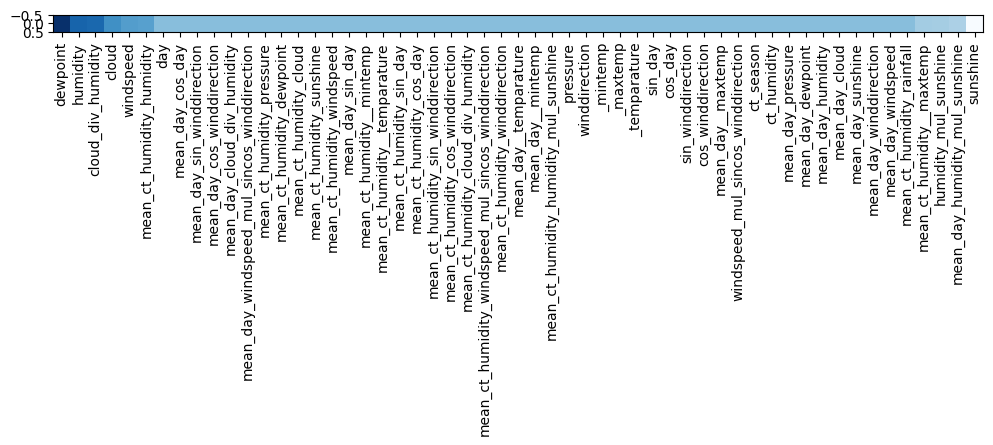

In [24]:
estimator = SGDClassifier(
    loss='log_loss',
    # learning_rate='adaptive',
    # eta0=0.001,
    alpha=0.001,
    penalty='l1',
    max_iter=15000,
    n_jobs=-1,
    # early_stopping=True,
    class_weight=CLASS_WEIGHTS.to_dict(),
    shuffle=False,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
estimator.fit(SGD_X, y)
linear_feature_importances(estimator, figsize=(12, 4))

__overview new features__

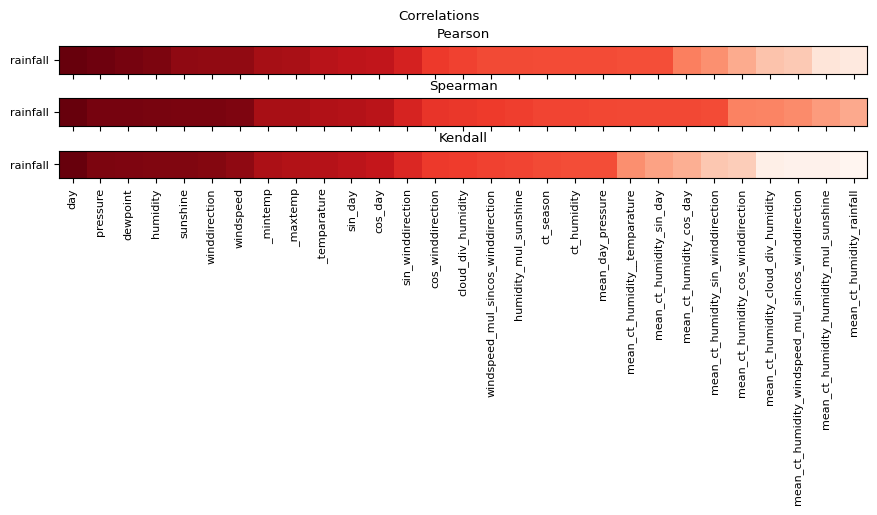

In [305]:
THRESHOLD = 0.075

data = X.copy()
labels = data.columns
data['rainfall'] = y

CORRELATIONS = ('pearson', 'spearman', 'kendall')
# CORRELATIONS = ('pearson', )
# drawing
fig, axes = plt.subplots(len(CORRELATIONS), 1, figsize=(12, 5), sharex=True)
fig.set_layout_engine('compressed')
fig.suptitle('Correlations')
for n, method in enumerate(CORRELATIONS):
    ax = axes[n] if len(CORRELATIONS) > 1 else axes
    ax.set_title(method.capitalize())
    rainfall_corr = data.corr(method)[['rainfall']].drop('rainfall').sort_values('rainfall', ascending=False)
    values = rainfall_corr.values.squeeze()
    filtered = (abs(values) > THRESHOLD)
    ax.imshow(values[filtered].reshape(1, -1), cmap='Reds')
    ax.set_xticks(range(len(labels[filtered])), labels=labels[filtered], rotation=90)
    ax.set_yticks([0], labels=['rainfall'])
plt.show()

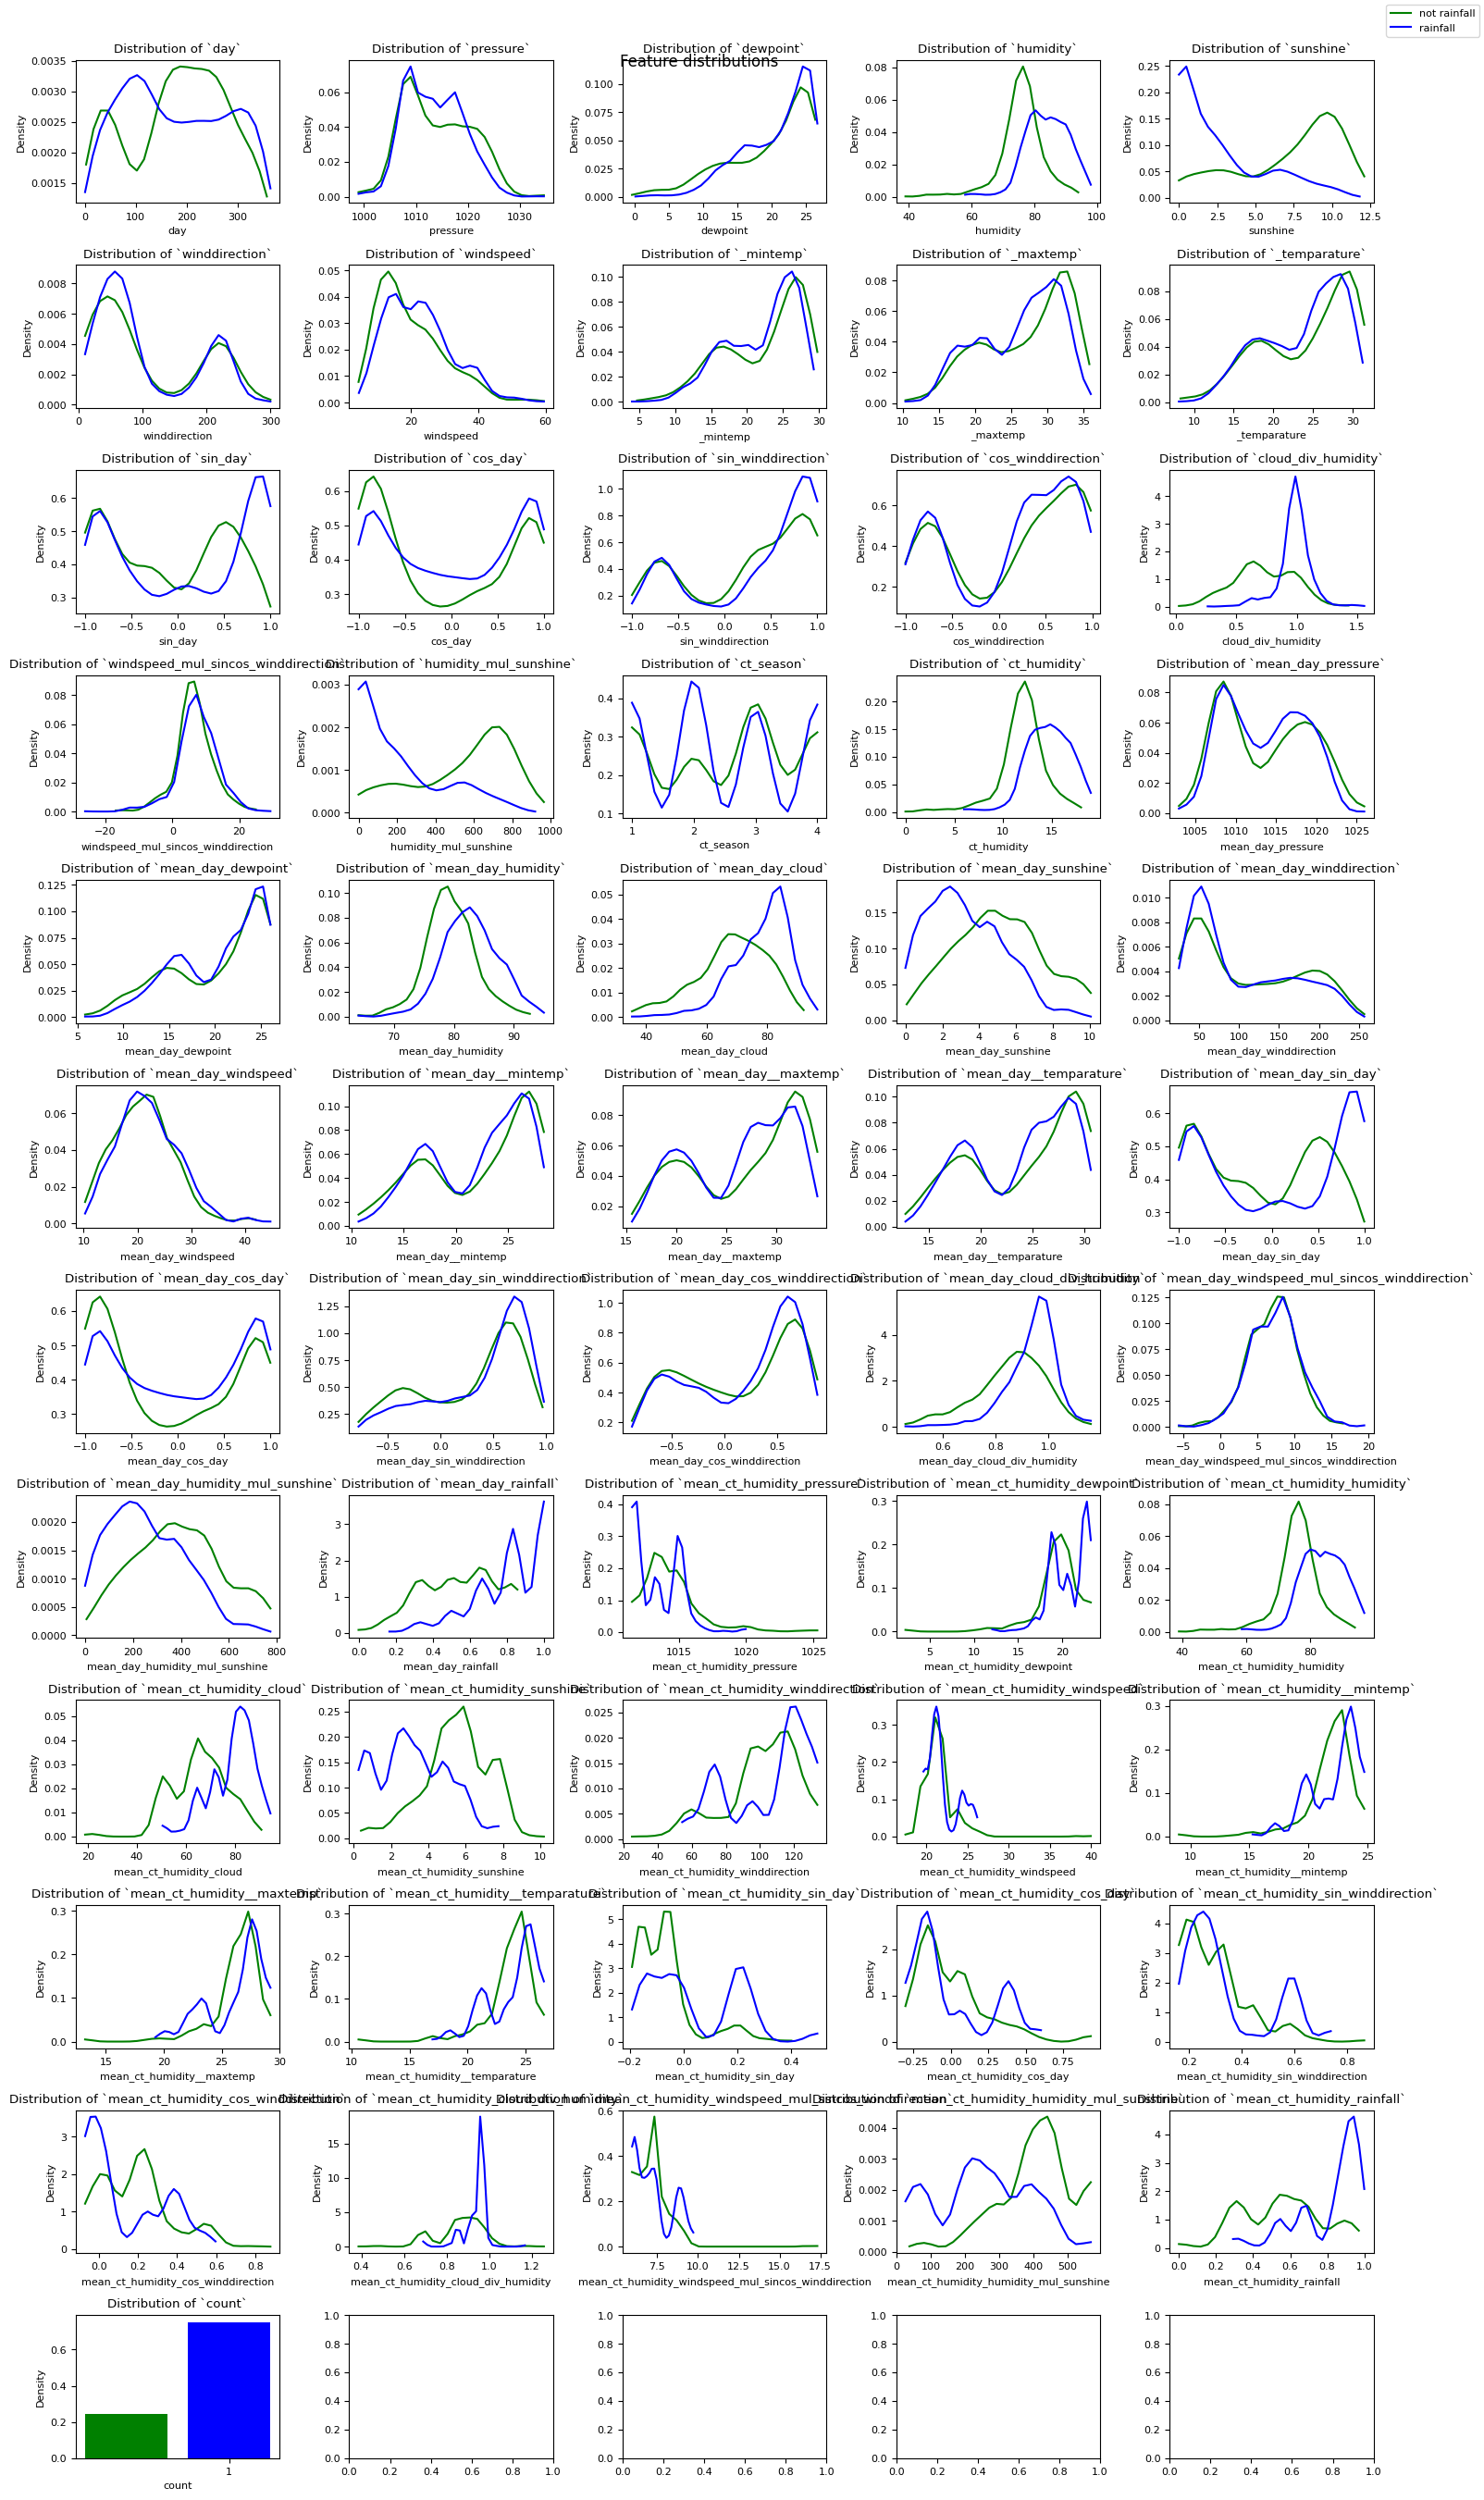

In [306]:
_filter = X.columns
# _filter = X.columns[X.columns.str.match(r'.*_index')]

_X = X[_filter].copy()
_X['rainfall'] = y

COLUMNS = 5
ROWS = max(np.ceil(len(_X.columns) / COLUMNS).astype(int), 2)
SIZE = (COLUMNS * 3, ROWS * 2.25)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')
for n, feature in enumerate(_X.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if feature == 'rainfall':
        feature_overview(ax[row][col], _X.loc[_X.rainfall == 0, feature].value_counts() / _X.shape[0], FigureType.BAR, color='green')
        feature_overview(ax[row][col], _X.loc[_X.rainfall == 1, feature].value_counts() / _X.shape[0], FigureType.BAR, color='blue')
        continue
    feature_overview(ax[row][col], _X.loc[_X.rainfall == 0, feature], FigureType.DENSITY, bins=25, color='green')
    feature_overview(ax[row][col], _X.loc[_X.rainfall == 1, feature], FigureType.DENSITY, bins=25, color='blue')

fig.legend(['not rainfall', 'rainfall'])
plt.show()

__modeling__

Fold: 0; TRAIN ROC AUC=0.89523; TRAIN f1=0.91300 | VALID ROC AUC=0.90097; VALID f1=0.92742
Fold: 1; TRAIN ROC AUC=0.89422; TRAIN f1=0.91425 | VALID ROC AUC=0.90286; VALID f1=0.91870
Fold: 2; TRAIN ROC AUC=0.89729; TRAIN f1=0.91417 | VALID ROC AUC=0.88191; VALID f1=0.90526
Fold: 3; TRAIN ROC AUC=0.89951; TRAIN f1=0.91609 | VALID ROC AUC=0.87563; VALID f1=0.91242
Fold: 4; TRAIN ROC AUC=0.89783; TRAIN f1=0.91615 | VALID ROC AUC=0.87753; VALID f1=0.90281
Fold: 5; TRAIN ROC AUC=0.89582; TRAIN f1=0.91460 | VALID ROC AUC=0.89443; VALID f1=0.92153
Fold: 6; TRAIN ROC AUC=0.89563; TRAIN f1=0.91664 | VALID ROC AUC=0.89264; VALID f1=0.90086
MEAN: TRAIN ROC AUC=0.89650; TRAIN f1=0.91498 | VALID ROC AUC=0.88942; VALID f1=0.91271


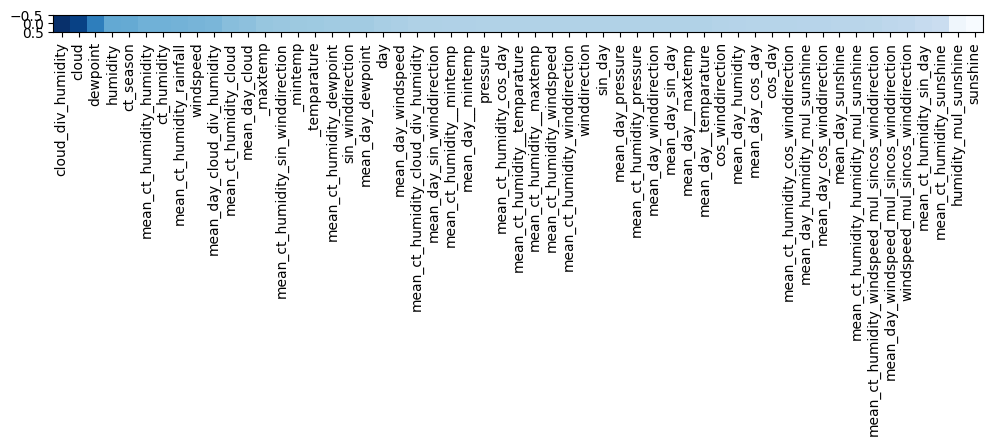

In [29]:
estimator = SGDClassifier(
    loss='log_loss',
    learning_rate='adaptive',
    eta0=0.001,
    alpha=0.001,
    penalty='l1',
    max_iter=15000,
    n_jobs=-1,
    # early_stopping=True,
    # class_weight=CLASS_WEIGHTS.to_dict(),
    shuffle=False,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
sgd = model = estimator.fit(SGD_X, y)
linear_feature_importances(model, figsize=(12, 4))

Fold: 0; TRAIN ROC AUC=0.90004; TRAIN f1=0.91399 | VALID ROC AUC=0.90114; VALID f1=0.92986
Fold: 1; TRAIN ROC AUC=0.89864; TRAIN f1=0.91661 | VALID ROC AUC=0.90139; VALID f1=0.92089
Fold: 2; TRAIN ROC AUC=0.90000; TRAIN f1=0.91647 | VALID ROC AUC=0.89397; VALID f1=0.90605
Fold: 3; TRAIN ROC AUC=0.90372; TRAIN f1=0.91718 | VALID ROC AUC=0.87081; VALID f1=0.91278
Fold: 4; TRAIN ROC AUC=0.90347; TRAIN f1=0.92023 | VALID ROC AUC=0.87454; VALID f1=0.90987
Fold: 5; TRAIN ROC AUC=0.90042; TRAIN f1=0.91615 | VALID ROC AUC=0.89192; VALID f1=0.91532
Fold: 6; TRAIN ROC AUC=0.90000; TRAIN f1=0.91888 | VALID ROC AUC=0.89109; VALID f1=0.90086
MEAN: TRAIN ROC AUC=0.90090; TRAIN f1=0.91707 | VALID ROC AUC=0.88927; VALID f1=0.91366


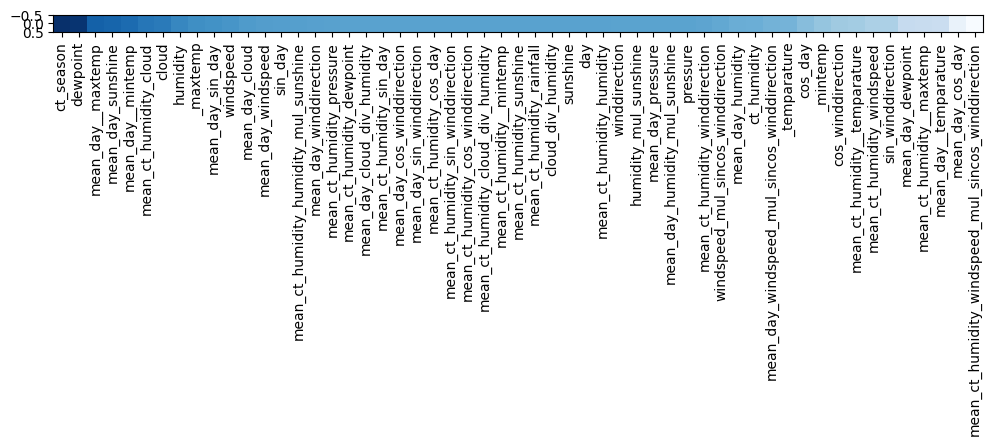

In [54]:
estimator = LogisticRegression(
    # solver='newton-cg',
    # penalty='l2',
    # penalty=None,
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    # class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
lin = model = estimator.fit(SGD_X, y)
linear_feature_importances(model, figsize=(12, 4))

In [59]:
# TOP = X.columns[model.coef_.argsort().squeeze()[::-1]][:25]
# # TOP

# _ = checkup(estimator, SGD_X.loc[:, TOP], y)
# lin = estimator.fit(SGD_X.loc[:, TOP], y)
# linear_feature_importances(model, figsize=(12, 4))

__validate on last train year__

In [ ]:
estimator = LogisticRegression(
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
    random_state=131,
)
Xt, Yt = SGD_X[:1825], y[:1825]
Xv, Yv = SGD_X[1825:], y[1825:]
estimator.fit(Xt, Yt)
pt = estimator.predict_proba(Xt).T[1]
pv = estimator.predict_proba(Xv).T[1]

auc_train = roc_auc_score(Yt, pt)
auc_valid = roc_auc_score(Yv, pv)
f1_train = f1_score(Yt, pt > 0.5)
f1_valid = f1_score(Yv, pv > 0.5)

auc_train, auc_valid, f1_train, f1_valid

(0.899329210774552, 0.8875636558563389, 0.9034879783271249, 0.9132569558101473)

In [43]:
from modeling import EnsembleMeta

ensemble = EnsembleMeta(LogisticRegression, n_estimators=100, random_state=13)(
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
)
_ = checkup(ensemble, SGD_X, y)
ens = model = ensemble.fit(SGD_X, y, verbose=True)

Fold: 0; TRAIN ROC AUC=0.95670; TRAIN f1=0.93847 | VALID ROC AUC=0.94092; VALID f1=0.93097
Fold: 1; TRAIN ROC AUC=0.95309; TRAIN f1=0.93527 | VALID ROC AUC=0.95675; VALID f1=0.94071
Fold: 2; TRAIN ROC AUC=0.95582; TRAIN f1=0.94003 | VALID ROC AUC=0.94250; VALID f1=0.92843
Fold: 3; TRAIN ROC AUC=0.95587; TRAIN f1=0.93995 | VALID ROC AUC=0.94101; VALID f1=0.92986
Fold: 4; TRAIN ROC AUC=0.95434; TRAIN f1=0.93932 | VALID ROC AUC=0.94715; VALID f1=0.93139
Fold: 5; TRAIN ROC AUC=0.95369; TRAIN f1=0.93397 | VALID ROC AUC=0.96393; VALID f1=0.95874
Fold: 6; TRAIN ROC AUC=0.95193; TRAIN f1=0.93511 | VALID ROC AUC=0.96041; VALID f1=0.93869
MEAN: TRAIN ROC AUC=0.95449; TRAIN f1=0.93744 | VALID ROC AUC=0.95038; VALID f1=0.93697


100%|██████████| 100/100 [00:03<00:00, 29.84it/s]


In [250]:
estimator = KNeighborsClassifier(
    # weights='uniform',
    algorithm='ball_tree',
    n_neighbors=50,
    p=1,
    # leaf_size=64,
    n_jobs=-1,
)
_ = checkup(estimator, SGD_X, y)
knn = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.88471; TRAIN f1=0.90471 | VALID ROC AUC=0.86373; VALID f1=0.90837
Fold: 1; TRAIN ROC AUC=0.88236; TRAIN f1=0.90734 | VALID ROC AUC=0.88932; VALID f1=0.91165
Fold: 2; TRAIN ROC AUC=0.88617; TRAIN f1=0.90741 | VALID ROC AUC=0.86433; VALID f1=0.89813
Fold: 3; TRAIN ROC AUC=0.88817; TRAIN f1=0.90476 | VALID ROC AUC=0.85319; VALID f1=0.90101
Fold: 4; TRAIN ROC AUC=0.88419; TRAIN f1=0.90798 | VALID ROC AUC=0.88735; VALID f1=0.90063
Fold: 5; TRAIN ROC AUC=0.88585; TRAIN f1=0.90909 | VALID ROC AUC=0.87771; VALID f1=0.90323
Fold: 6; TRAIN ROC AUC=0.88685; TRAIN f1=0.90630 | VALID ROC AUC=0.86389; VALID f1=0.90672
MEAN: TRAIN ROC AUC=0.88547; TRAIN f1=0.90680 | VALID ROC AUC=0.87136; VALID f1=0.90425


__wah lol__

Fold: 0; TRAIN ROC AUC=0.89921; TRAIN f1=0.89190 | VALID ROC AUC=0.89880; VALID f1=0.90446
Fold: 1; TRAIN ROC AUC=0.89947; TRAIN f1=0.89190 | VALID ROC AUC=0.90467; VALID f1=0.90129
Fold: 2; TRAIN ROC AUC=0.90092; TRAIN f1=0.89880 | VALID ROC AUC=0.88499; VALID f1=0.88641
Fold: 3; TRAIN ROC AUC=0.90347; TRAIN f1=0.89393 | VALID ROC AUC=0.86762; VALID f1=0.87473
Fold: 4; TRAIN ROC AUC=0.90199; TRAIN f1=0.89478 | VALID ROC AUC=0.88125; VALID f1=0.88435
Fold: 5; TRAIN ROC AUC=0.89947; TRAIN f1=0.89394 | VALID ROC AUC=0.89314; VALID f1=0.89496
Fold: 6; TRAIN ROC AUC=0.90026; TRAIN f1=0.89957 | VALID ROC AUC=0.88048; VALID f1=0.90000
MEAN: TRAIN ROC AUC=0.90068; TRAIN f1=0.89497 | VALID ROC AUC=0.88728; VALID f1=0.89231


100%|██████████| 20/20 [01:00<00:00,  3.02s/it]


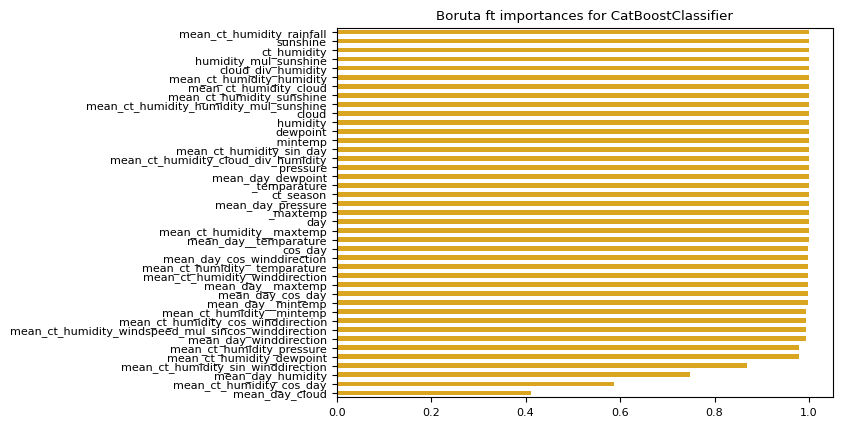

In [401]:
estimator = CatBoostClassifier(
    n_estimators=1500,
    # iterations=1500,
    learning_rate=0.001,
    depth=3,
    class_weights=CLASS_WEIGHTS,
    random_state=19,
    verbose=False,
    allow_writing_files=False,
)
_ = checkup(estimator, X, y, folds=7)
importances = boruta(X, y, estimator.copy(), seed=10, plot=True, alpha=0.95)
catboost = model = estimator.fit(X, y)

__submission__

In [5]:
# SGD
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = sgd.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

8c2318f4f88b400c8428bb01c480bce6


In [ ]:
# logistic regression
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = lin.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

In [ ]:
# logistic regression ensemble
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = ens.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

In [72]:
# KNeighbours
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = knn.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

3f68538198664f9291e4c98f637ce572


In [ ]:
# CatBoost LOL
T = pipes['base'].transform(test.drop(columns='rainfall'))
rainfall = catboost.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

b5c1648db89343d191cbd8f500ebbc87


__NN approach__

In [1]:
import torch
import torch.optim as opt
import torch.utils.data
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [4]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y = None, size: int = 3):
        self.x = X.values.reshape(*X.shape, 1)
        self.y = y.values.reshape(-1, 1) if y is not None else None
        self.size = size

    def __getitem__(self, index):
        """Return item with N previous items"""
        x_bundle, y_bundle = [], []
        for step in range(self.size):
            if (idx := index - step) < 0:
                idx = index
            x_bundle.append(torch.as_tensor(self.x[idx], dtype=torch.float32))
        return (
            torch.concat(x_bundle, dim=-1).reshape(self.size, -1),
            torch.as_tensor(self.y[index], dtype=torch.float32) if self.y is not None else None
        )

    def __len__(self):
        return self.x.shape[0]

dataset = Dataset(SGD_X, y, size=3)
dataset[0][0].shape

torch.Size([3, 55])

In [5]:
class ShowShape(torch.nn.Module):
    def forward(self, X, *args, **kw):
        print(f'{X.shape=}')
        return X


class Model:
    def __init__(
            self,
            days: int,
            features: int,
            hidden_channels: int | None = None,
            linear_channels: int = 64,
            criterion: torch.nn.modules.loss._Loss = torch.nn.BCELoss(),
            optimizer: type[torch.optim.Optimizer] = opt.Adam,
            device: Literal['cpu', 'cuda'] = 'cpu',
            **optimizer_params
    ):
        self.device = device
        self.days = days
        CHANNELS = hidden_channels or (days // 2 + (not days // 2))
        self.model = torch.nn.Sequential(
            # first conv
            torch.nn.Conv1d(days, CHANNELS, kernel_size=days),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=2),
            # linears
            torch.nn.Flatten(1),
            torch.nn.Linear(CHANNELS * ((features - days + 1) // 2), linear_channels // 2),

            # # first conv
            # torch.nn.Conv1d(days, CHANNELS, kernel_size=2 if days > 1 else 1),
            # torch.nn.ReLU(),
            # torch.nn.MaxPool1d(kernel_size=2),
            # # second conv
            # torch.nn.Conv1d(CHANNELS, days, kernel_size=days - 1),
            # torch.nn.ReLU(),
            # torch.nn.MaxPool1d(kernel_size=2),
            # # linears
            # torch.nn.Flatten(1),
            # torch.nn.Linear(days * ((((features - days + 1) // 2) - (days > 2)) // 2), linear_channels // 2),

            torch.nn.ReLU(),
            torch.nn.Dropout(0.25),
            torch.nn.Linear(linear_channels // 2, linear_channels // 4),
            torch.nn.ReLU(),
            torch.nn.Linear(linear_channels // 4, 1),
            torch.nn.Sigmoid(),
        )
        self.model.compile()
        self.optimizer = optimizer(self.model.parameters(), **optimizer_params)
        self.criterion = criterion

    def fit(self, X, y, epochs: int = 5, batch_size: int = 32, verbose: bool = True):
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
        # fit
        self.model.to(self.device)
        self.model.train()
        for ep in range(epochs):
            sum_loss, items = 0.0, 0
            if verbose:
                pbar = tqdm(enumerate(loader), total=len(loader), desc=f'Epoch {ep + 1}/{epochs}')
            else:
                pbar = enumerate(loader)
            for i, batch in pbar:
                inputs, labels = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                # calc loss
                sum_loss += loss.item()
                items += len(labels)
                if verbose and isinstance(pbar, tqdm):
                    pbar.set_postfix({'cumulative loss per item': sum_loss / items})
        self.model.eval()

    def predict_proba(self, X):
        assert self.model is not None, 'Model is not trained'
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=X.shape[0])
        predictions = self.model.forward(next(iter(loader))[0])
        return predictions.detach()

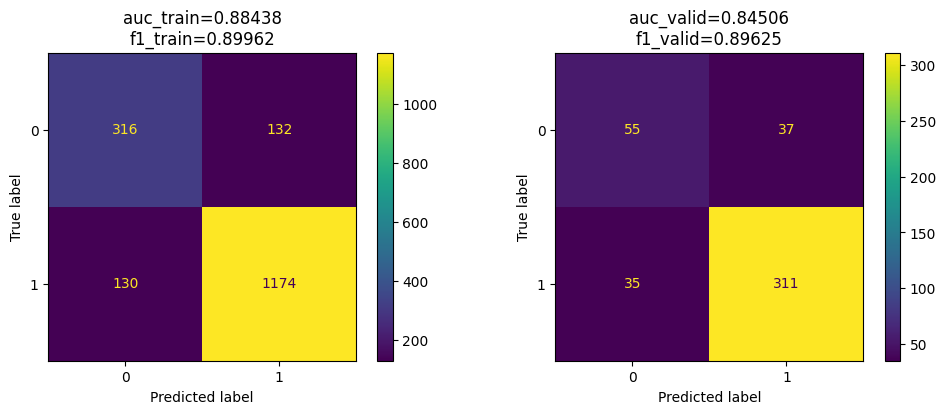

In [42]:
torch.manual_seed(11)
DAYS = 3
dataset = Dataset(SGD_X, y, size=DAYS)

model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    hidden_channels=1,
    linear_channels=72,
    criterion=torch.nn.BCELoss(),
    # criterion=torch.nn.HuberLoss(delta=0.8),
    lr=0.01,
)
X_train, X_valid, y_train, y_valid = train_test_split(SGD_X, y, test_size=0.2, shuffle=False, random_state=19)
model.fit(X_train, y_train, epochs=50, batch_size=1024, verbose=False)

# predicting
y_pred_train = model.predict_proba(X_train)
y_pred_valid = model.predict_proba(X_valid)
# scoring
auc_train = roc_auc_score(y_train, y_pred_train)
auc_valid = roc_auc_score(y_valid, y_pred_valid)
f1_train = f1_score(y_train, y_pred_train > 0.5)
f1_valid = f1_score(y_valid, y_pred_valid > 0.5)
# drawing
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train.numpy() > 0.5, ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_valid.numpy() > 0.5, ax=ax[1])
ax[0].set_title(f'{auc_train=:.5f}\n{f1_train=:.5f}')
ax[1].set_title(f'{auc_valid=:.5f}\n{f1_valid=:.5f}')
plt.show()

__NN cross validation__

In [11]:
def nn_checkup(estimator_base, X, y, folds=7, **fit_params):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train], **fit_params)

        pt = estimator.predict_proba(X.loc[train]).numpy()
        pv = estimator.predict_proba(X.loc[valid]).numpy()

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


torch.manual_seed(11)
_ = nn_checkup(model, SGD_X, y, epochs=10, batch_size=512, verbose=False)

Fold: 0; TRAIN ROC AUC=0.98836; TRAIN f1=0.96628 | VALID ROC AUC=0.96456; VALID f1=0.94456
Fold: 1; TRAIN ROC AUC=0.98746; TRAIN f1=0.96818 | VALID ROC AUC=0.96484; VALID f1=0.94168
Fold: 2; TRAIN ROC AUC=0.98681; TRAIN f1=0.96375 | VALID ROC AUC=0.97001; VALID f1=0.95781
Fold: 3; TRAIN ROC AUC=0.98711; TRAIN f1=0.96469 | VALID ROC AUC=0.97386; VALID f1=0.94194
Fold: 4; TRAIN ROC AUC=0.98554; TRAIN f1=0.96729 | VALID ROC AUC=0.98052; VALID f1=0.95258
Fold: 5; TRAIN ROC AUC=0.98709; TRAIN f1=0.96424 | VALID ROC AUC=0.96645; VALID f1=0.95616
Fold: 6; TRAIN ROC AUC=0.98693; TRAIN f1=0.96415 | VALID ROC AUC=0.96104; VALID f1=0.94348
MEAN: TRAIN ROC AUC=0.98704; TRAIN f1=0.96551 | VALID ROC AUC=0.96875; VALID f1=0.94831


__final fit__

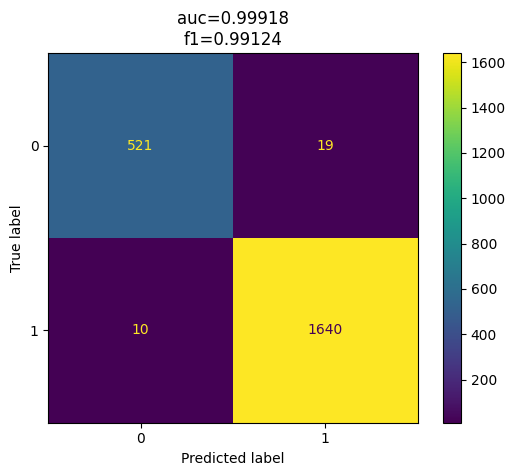

In [12]:
torch.manual_seed(11)
DAYS = 2
dataset = Dataset(SGD_X, y, size=DAYS)

cnn = model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    hidden_channels=8,
    linear_channels=96,
    criterion=torch.nn.BCELoss(),
    lr=0.01,
)
model.fit(SGD_X, y, epochs=250, batch_size=1024, verbose=False)

predictions = model.predict_proba(SGD_X)
auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions.numpy() > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [13]:
# CNN
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = cnn.predict_proba(T)

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

9c500742969546809c17128740a06861


__mix predictions__

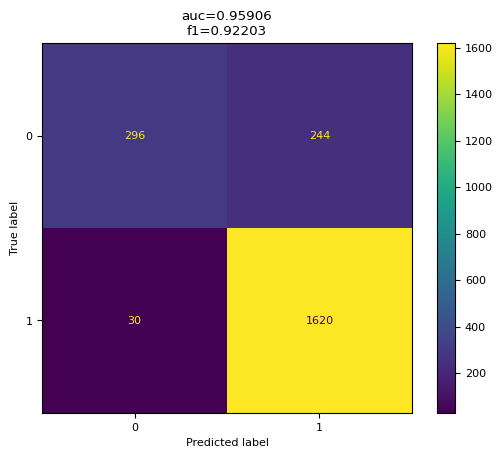

In [307]:
weights = np.array([0.3, 0.4, 0.3]).reshape(3, 1)

predictions = sum(weights * np.array((
    sgd.predict_proba(SGD_X)[:, 1],
    lin.predict_proba(SGD_X)[:, 1],
    # knn.predict_proba(SGD_X)[:, 1],
    # catboost.predict_proba(X)[:, 1],
    cnn.predict_proba(SGD_X).numpy()[:, 0],
)))

auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [36]:
T1 = pipes['base'].transform(test.drop(columns='rainfall'))
T2 = pipes['sgd'].transform(test.drop(columns='rainfall'))

rainfall = sum(weights * np.array((
    sgd.predict_proba(T2)[:, 1],
    lin.predict_proba(T2)[:, 1],
    knn.predict_proba(T2)[:, 1],
    # catboost.predict_proba(T1)[:, 1],
    cnn.predict_proba(T2).numpy()[:, 0]
)))
if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

c31d0ac049f346939ce388c0c5eaa524


In [ ]:
#